In [2]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
weights = models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT

model = models.segmentation.deeplabv3_resnet50(weights=weights)

model.eval()

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /home/prakash/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:36<00:00, 4.56MB/s] 


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu):

In [7]:
image_path = "../../datasets/object_detection/image2.jpg"

image = Image.open(image_path).convert("RGB")
preprocess = weights.transforms()

input_tensor = preprocess(image)

input_batch = input_tensor.unsqueeze(0)
with torch.no_grad():
    output = model(input_batch)
print("Output dictionary keys:")
print(output.keys())
print("Output tensor shape:")
print(output["out"].shape)
pred_mask = output["out"].argmax(dim=1)

print("Predicted mask shape:")
print(pred_mask.shape)

Output dictionary keys:
odict_keys(['out', 'aux'])
Output tensor shape:
torch.Size([1, 21, 520, 859])
Predicted mask shape:
torch.Size([1, 520, 859])


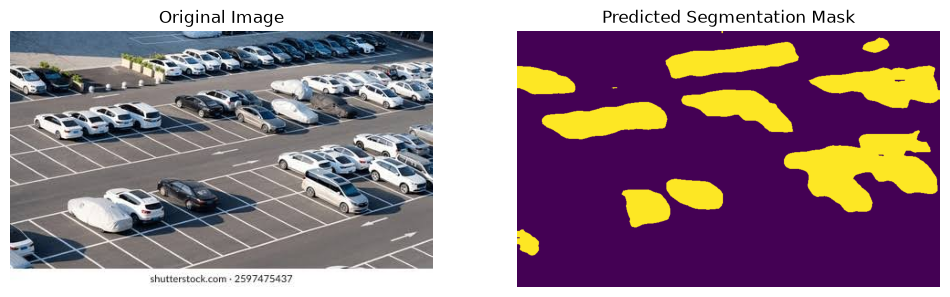

In [8]:
pred_mask = pred_mask.squeeze(0)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred_mask.cpu(), cmap="viridis")
plt.title("Predicted Segmentation Mask")
plt.axis("off")

plt.show()